In [54]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [55]:
df=sns.load_dataset("iris")

In [56]:
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [57]:
print(df.tail(10))

     sepal_length  sepal_width  petal_length  petal_width    species
140           6.7          3.1           5.6          2.4  virginica
141           6.9          3.1           5.1          2.3  virginica
142           5.8          2.7           5.1          1.9  virginica
143           6.8          3.2           5.9          2.3  virginica
144           6.7          3.3           5.7          2.5  virginica
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica


In [58]:
print("shapes",df.shape)

shapes (150, 5)


In [59]:
print("columns:",df.columns.tolist())

columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


In [60]:
print(df.dtypes)

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [62]:
print(df.isnull().sum())

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [63]:
print("Total string values:",df.isnull().sum().sum())

Total string values: 0


In [64]:
print("Number of rows:",len(df))

Number of rows: 150


In [65]:
print("Number of columns:",df.shape[1])

Number of columns: 5


In [66]:
print(df["species"].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [67]:
print(df["species"].value_counts(normalize=True)*100)

species
setosa        33.333333
versicolor    33.333333
virginica     33.333333
Name: proportion, dtype: float64


In [68]:
print("Number of unique species:",df["species"].nunique())

Number of unique species: 3


In [69]:
print("species:",df["species"].unique())

species: ['setosa' 'versicolor' 'virginica']


In [70]:
print(df.describe())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [71]:
print(df.select_dtypes("number").mean())

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64


In [72]:
print(df.select_dtypes("number").median())

sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64


In [73]:
print(df.select_dtypes("number").mode())

   sepal_length  sepal_width  petal_length  petal_width
0           5.0          3.0           1.4          0.2
1           NaN          NaN           1.5          NaN


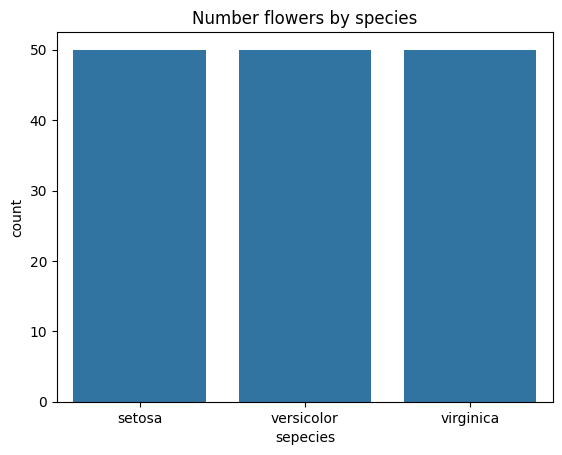

In [74]:
sns.countplot(data=df,x="species")
plt.title("Number flowers by species")
plt.xlabel("sepecies")
plt.ylabel("count")
plt.show()

<Axes: xlabel='sepal_length', ylabel='Count'>

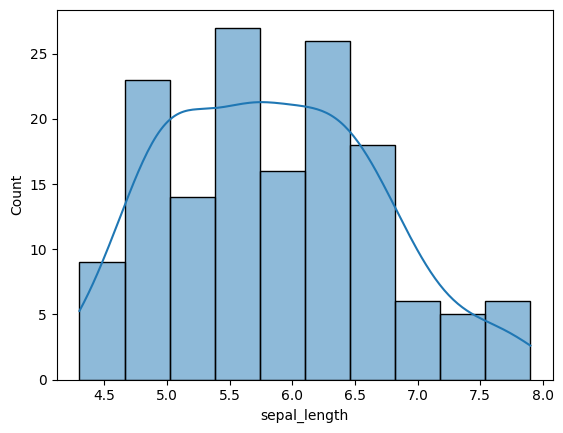

In [75]:
sns.histplot(
    data=df,
    x="sepal_length",
    bins=10,
    kde=True
)

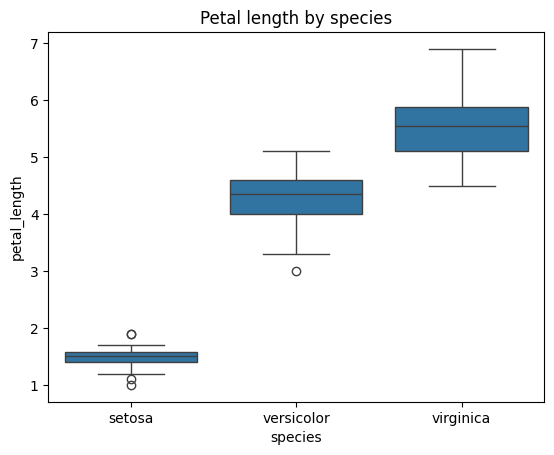

In [76]:
sns.boxplot(
    data=df,
    x="species",
    y="petal_length"
)
plt.title("Petal length by species")
plt.show()

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import statsmodels.formula.api as smf

In [78]:
url="https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df=pd.read_csv(url)

In [79]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [80]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


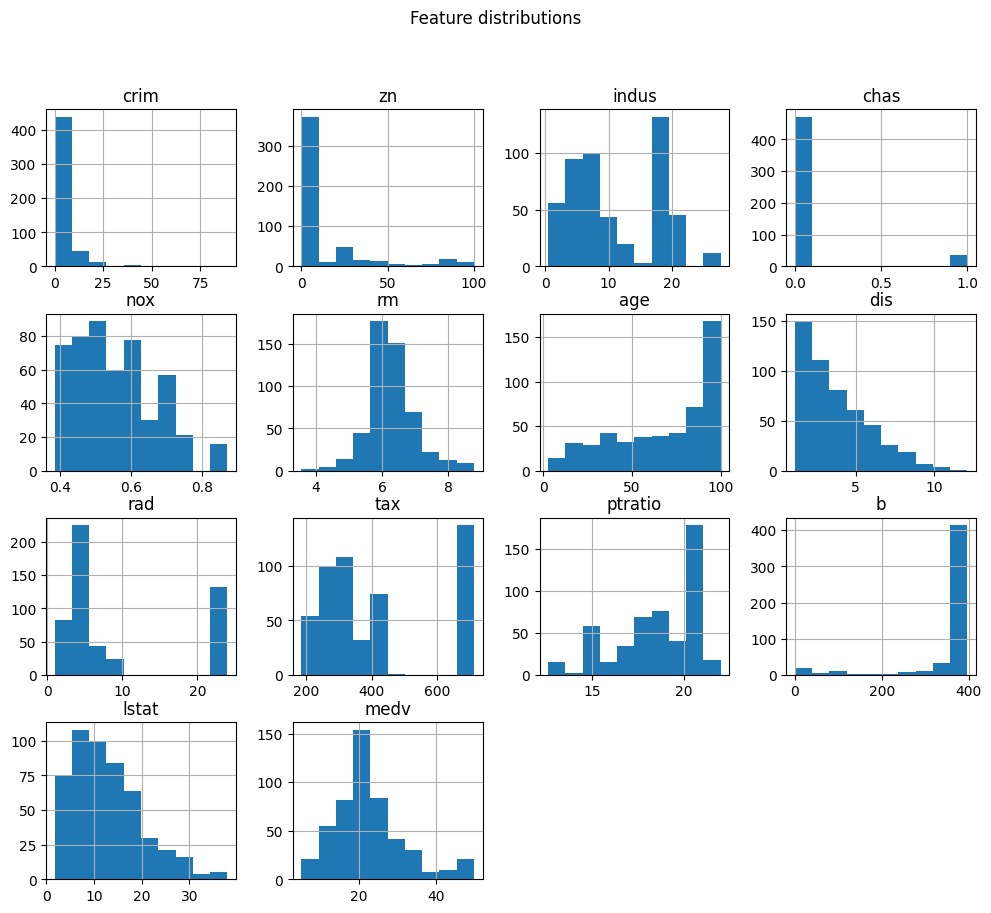

In [81]:
df.hist(figsize=(12,10))
plt.suptitle("Feature distributions")
plt.show()

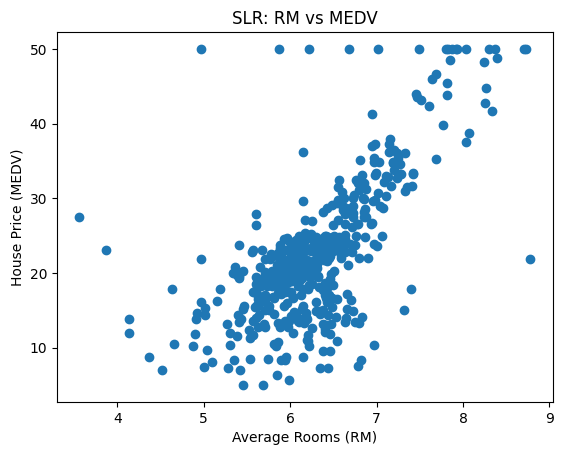

In [82]:

plt.scatter(df['rm'], df['medv'])
plt.xlabel("Average Rooms (RM)")
plt.ylabel("House Price (MEDV)")
plt.title("SLR: RM vs MEDV")
plt.show()


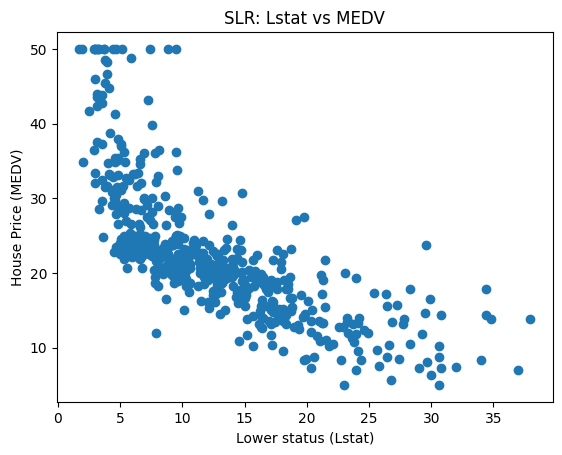

In [83]:

plt.scatter(df['lstat'], df['medv'])
plt.xlabel("Lower status (Lstat)")
plt.ylabel("House Price (MEDV)")
plt.title("SLR: Lstat vs MEDV")
plt.show()

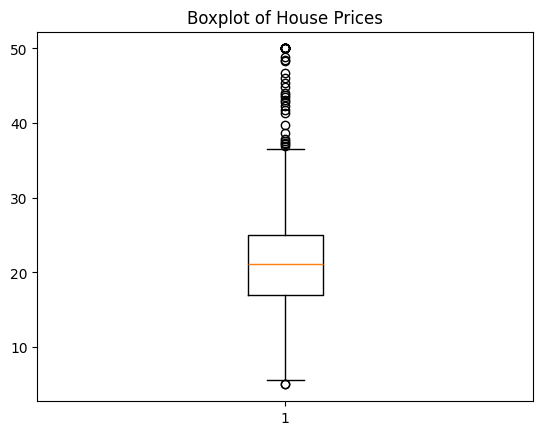

In [84]:

plt.boxplot(df['medv'])
plt.title("Boxplot of House Prices")
plt.show()


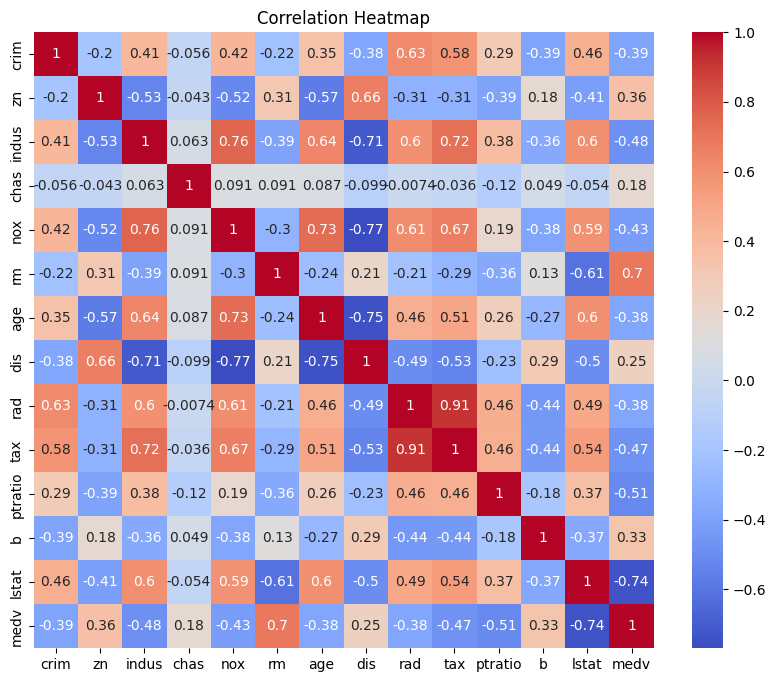

In [85]:

plt.figure(figsize=(10,8))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [86]:

X_slr = df[['rm']]
y = df['medv']

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X_slr, y, test_size=0.3, random_state=565)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((354, 1), (152, 1), (354,), (152,))

In [88]:
slr = LinearRegression()
slr.fit(X_train, y_train)

LinearRegression()

In [89]:
y_pred_slr = slr.predict(X_test)
y_pred_slr

array([19.54976259, 18.31258722, 19.15813873, 41.20478186, 23.77752015,
       16.65708636, 21.55238459, 24.63197221, 23.60840985, 21.50788188,
       25.45972264, 21.1963629 , 17.4670357 , 27.40004084, 19.63876801,
       30.16810948, 19.14033765, -1.64242849, 17.24452215, 19.78117669,
        8.0680631 , 17.94766499, 13.58639929, 30.5508328 , 21.40997592,
       17.92096336, 16.78169395, 20.98274989, 17.67174818, 27.66705711,
       23.7241169 , 16.25656196, 35.07230826, 30.61313659, 24.97909336,
       24.38275703, 21.14295965, 19.1314371 , 23.16338274, 23.6618131 ,
       15.19739743, 25.34401559, 29.18014929, 16.23876088, 10.3020992 ,
       27.29323434, 25.219408  , 21.21416399, 24.14244238, 28.53040971,
       23.40369738, 21.78379869, 16.19425816, 29.89219267, 20.92044609,
       18.44609535, 20.80473904, 16.75499233, 22.82516213, 21.50788188,
       26.52778771, 25.62883294, 23.37699575, 14.96598333, 17.63614601,
       21.86390357, 22.21992526, 26.54558879, 28.75292327, 20.63

In [90]:
print("\nSLR Results")
print("\nSLR Results")
print("R2:", r2_score(y_test, y_pred_slr))


SLR Results

SLR Results
R2: 0.5525286822355802


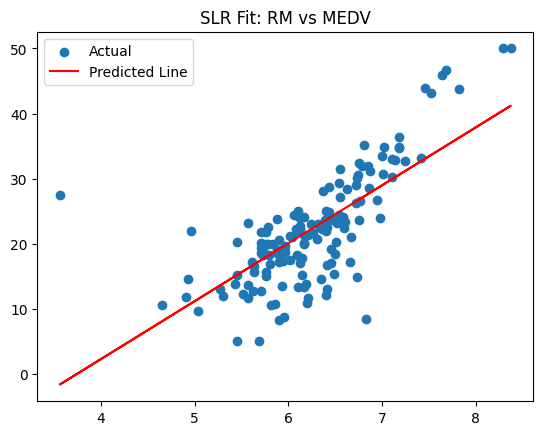

In [91]:

plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred_slr, color='red', label="Predicted Line")
plt.title("SLR Fit: RM vs MEDV")
plt.legend()
plt.show()


In [92]:

X_mlr = df[['rm', 'lstat', 'ptratio']]

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X_mlr, y, test_size=0.3, random_state=42)

In [94]:
mlr = LinearRegression()
mlr.fit(X_train, y_train)
y_pred_mlr = mlr.predict(X_test)
y_pred_mlr

array([26.92298627, 30.93686434, 16.47934188, 25.25409179, 18.28052198,
       22.71776451, 17.48030837, 12.67868396, 20.65299142, 19.72674849,
       19.62053908, 21.39117368, -1.63888554, 22.28305258, 19.5334365 ,
       24.73953404, 17.1762308 ,  3.83959545, 39.02235903, 17.25781087,
       25.90189855, 27.47962656, 11.74316928, 23.53277967, 17.93698432,
       13.86981688, 22.65619649, 19.32774678, 18.15760126, 18.82706414,
       19.72132643, 25.49788496, 25.14274849, 18.4146037 , 14.50579644,
       21.30312278, 32.36532273, 20.91382657, 20.20888187, 24.82872147,
       12.74319123, 28.21994868, 39.52761971, 18.8078418 , 26.03183697,
       15.77223641, 14.27426728, 26.09480414, 18.29649761, 31.22324968,
       23.74269632, 33.559009  , 16.01682884, 25.67415581, 38.30791834,
       22.41596988, 18.34605716, 30.13739458, 24.81027677, 15.41857328,
       25.51195584, 32.09021934, 30.05047579, 17.23144792, 28.34222612,
       11.86980665, 19.1480674 , 25.75429805, 29.12514764, 15.79

In [95]:
print("\nMLR Results")
print("R2:", r2_score(y_test, y_pred_mlr))


MLR Results
R2: 0.650904156861472


In [96]:
# Coefficients
coef_df = pd.DataFrame({
    "Feature": X_mlr.columns,
    "Coefficient": mlr.coef_
})
print(coef_df)

   Feature  Coefficient
0       rm     4.461626
1    lstat    -0.608150
2  ptratio    -0.862905


In [97]:

pred_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_mlr
})

pred_df.head()


,Actual,Predicted
0,23.6,26.922986
1,32.4,30.936864
2,13.6,16.479342
3,22.8,25.254092
4,16.1,18.280522


In [98]:

ols_model = smf.ols(formula="medv ~ rm + lstat + ptratio",data=df).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     353.3
Date:                Tue, 01 Sep 2026   Prob (F-statistic):          2.69e-123
Time:                        06:55:10   Log-Likelihood:                -1553.0
No. Observations:                 506   AIC:                             3114.
Df Residuals:                     502   BIC:                             3131.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     18.5671      3.913      4.745      0.0